# Fashion Florence — LoRA Fine-Tuning on Google Colab

Fine-tune **Microsoft Florence-2** with LoRA to output structured fashion tags (category, color, material, style, occasion) from clothing images.

**Requirements:** GPU runtime (T4 or better). Go to *Runtime → Change runtime type → T4 GPU*.

## 1 · Setup & Dependencies

In [1]:
!pip install -q torch torchvision transformers peft datasets pillow accelerate

In [3]:
import torch, sys, os

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
if device == "cuda":
    props = torch.cuda.get_device_properties(0)
    print(f"GPU: {props.name}")
    vram = getattr(props, "total_global_mem", None) or getattr(props, "total_mem", 0)
    print(f"VRAM: {vram / 1e9:.1f} GB")
else:
    print("WARNING: No GPU detected — training will be extremely slow.")

Device: cuda
GPU: Tesla T4
VRAM: 0.0 GB


### Clone the repo (skip if you uploaded the project manually)

In [11]:
!git clone https://github.com/anushreeberlia/fashion-florence.git

Cloning into 'fashion-florence'...
remote: Enumerating objects: 27, done.
remote: Counting objects: 100% (27/27), done.
remote: Compressing objects: 100% (18/18), done.
remote: Total 27 (delta 8), reused 25 (delta 6), pack-reused 0 (from 0)
Receiving objects: 100% (27/27), 28.53 KiB | 5.71 MiB/s, done.
Resolving deltas: 100% (8/8), done.


## 2 · Prepare Dataset from Hugging Face

Downloads images from `Marqo/iMaterialist`, maps iMaterialist labels → Fashion Florence schema, and writes train/val/test JSONL splits.

In [12]:
MAX_ROWS = 5000  # increase for a better model (10k+ recommended), decrease for a quick test run
HF_DATASET = "Marqo/iMaterialist"
HF_SPLIT = "data"
IMAGES_DIR = "data/raw/images"
PROCESSED_DIR = "data/processed"

In [13]:
%cd /content/fashion-florence
!pwd
!ls -la
!git status

/content/fashion-florence
/content/fashion-florence
total 36
drwxr-xr-x 5 root root 4096 Mar  5 06:28 .
drwxr-xr-x 1 root root 4096 Mar  5 06:28 ..
drwxr-xr-x 2 root root 4096 Mar  5 06:28 data
-rw-r--r-- 1 root root 6148 Mar  5 06:28 .DS_Store
drwxr-xr-x 8 root root 4096 Mar  5 06:28 .git
-rw-r--r-- 1 root root   79 Mar  5 06:28 .gitignore
-rw-r--r-- 1 root root  555 Mar  5 06:28 README.md
drwxr-xr-x 3 root root 4096 Mar  5 06:28 training
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [24]:
!git pull origin main

remote: Enumerating objects: 12, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 7 (delta 5), reused 7 (delta 5), pack-reused 0 (from 0)
Unpacking objects: 100% (7/7), 2.42 MiB | 11.49 MiB/s, done.
From https://github.com/anushreeberlia/fashion-florence
 * branch            main       -> FETCH_HEAD
   4ebce79..5f41236  main       -> origin/main
Updating 4ebce79..5f41236
Fast-forward
 train_colab.ipynb           | 1095 +++++++++++++++++++++++++++++++++++++++++++
 training/label_mapping.py   |   63 +++
 training/prepare_dataset.py |   16 +-
 training/train_lora.py      |    1 -
 4 files changed, 1170 insertions(+), 5 deletions(-)
 create mode 100644 train_colab.ipynb


In [25]:
!python training/prepare_dataset.py \
  --hf-dataset Marqo/iMaterialist \
  --hf-split data \
  --max-rows 10000 \
  --hf-images-dir data/raw/images \
  --out-dir data/processed \
  --train-ratio 0.8 \
  --val-ratio 0.1 \
  --test-ratio 0.1 \
  --seed 42

Resolving data files: 100% 153/153 [00:00<00:00, 433600.35it/s]
Resolving data files: 100% 153/153 [00:00<00:00, 27930.38it/s]
Dataset prep complete:
{
  "source": "Marqo/iMaterialist",
  "raw_rows": 10000,
  "kept_rows": 3841,
  "skipped_rows": 2185,
  "missing_images": 0,
  "invalid_target_rows": 3974,
  "split_counts": {
    "train": 3072,
    "val": 384,
    "test": 385
  },
  "category_counts": {
    "top": 1202,
    "bottom": 778,
    "dress": 1380,
    "layer": 420,
    "shoes": 59,
    "accessory": 2
  }
}


In [27]:
import json
from pathlib import Path

stats_path = Path(PROCESSED_DIR) / "stats.json"
stats = json.loads(stats_path.read_text())
print(json.dumps(stats, indent=2))

{
  "source": "Marqo/iMaterialist",
  "raw_rows": 10000,
  "kept_rows": 3841,
  "skipped_rows": 2185,
  "missing_images": 0,
  "invalid_target_rows": 3974,
  "split_counts": {
    "train": 3072,
    "val": 384,
    "test": 385
  },
  "category_counts": {
    "top": 1202,
    "bottom": 778,
    "dress": 1380,
    "layer": 420,
    "shoes": 59,
    "accessory": 2
  }
}


### Preview a few training examples

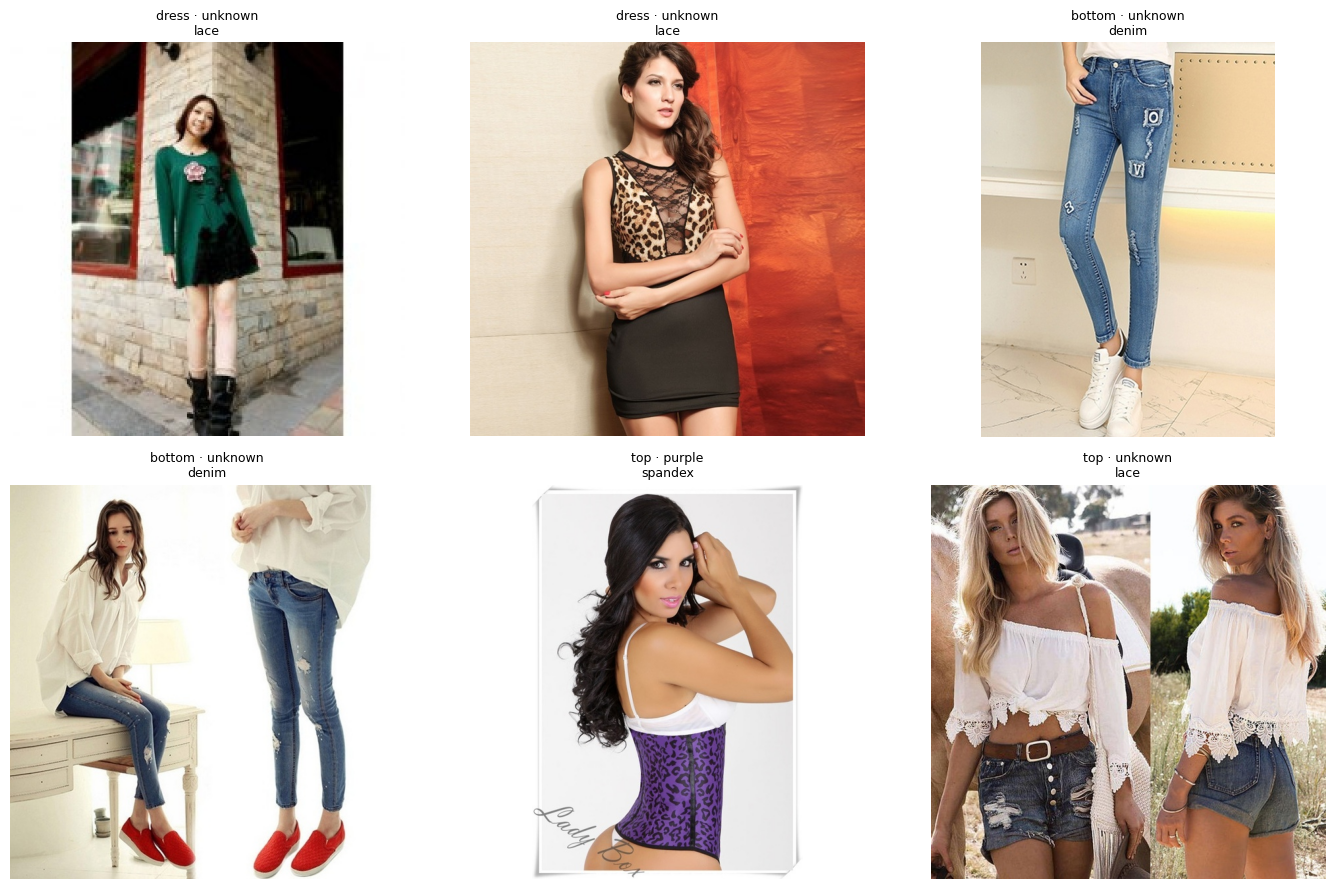

In [28]:
import matplotlib.pyplot as plt
from PIL import Image

train_path = Path(PROCESSED_DIR) / "train.jsonl"
rows = [json.loads(line) for line in train_path.read_text().strip().splitlines()[:6]]

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
for ax, row in zip(axes.flat, rows):
    img = Image.open(row["image_path"]).convert("RGB")
    target = json.loads(row["target"])
    label = f"{target['category']} · {target['primary_color']}\n{target.get('material', '?')}"
    ax.imshow(img)
    ax.set_title(label, fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

Resolving data files:   0%|          | 0/153 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/153 [00:00<?, ?it/s]

Row 0: category=Jumpsuits Overalls & Rompers, color=None, material=Polyester


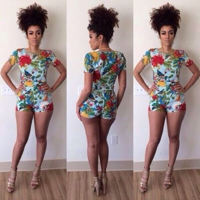

Row 1: category=Swimsuit Cover-ups, color=None, material=Chiffon


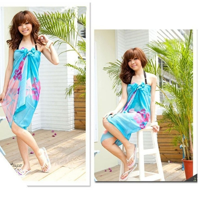

Row 2: category=Lingerie Sleepwear & Underwear, color=Black, material=None


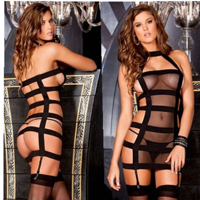

Row 3: category=Jumpsuits Overalls & Rompers, color=None, material=None


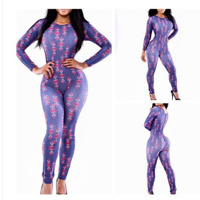

Row 4: category=Swim Trunks, color=Black, material=Spandex


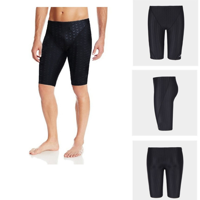

Row 5: category=Dresses, color=Black White, material=Polyester Spandex


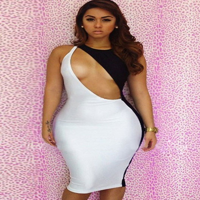

Row 6: category=Fashion Sets, color=None, material=None


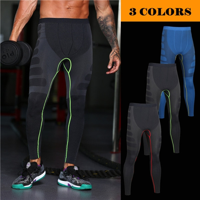

Row 7: category=Wedding Dresses, color=None, material=None


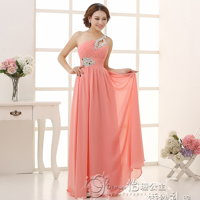

Row 8: category=Dresses, color=None, material=None


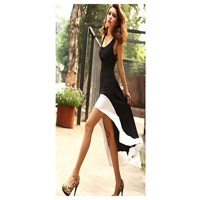

Row 9: category=Party Dresses, color=None, material=None


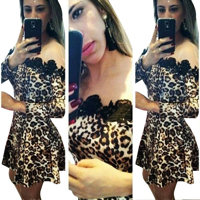

Row 10: category=Jeans, color=None, material=Denim


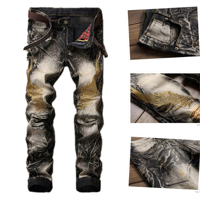

Row 11: category=None, color=Black White, material=None


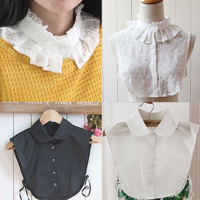

Row 12: category=Casual Dresses, color=None, material=Chiffon


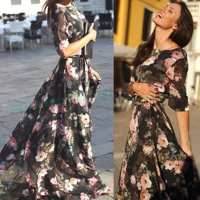

Row 13: category=Hoodies & Sweatshirts, color=None, material=None


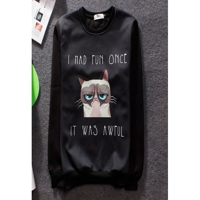

Row 14: category=Dresses, color=White, material=Chiffon


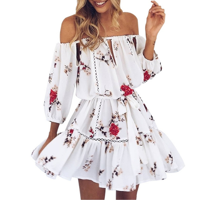

Row 15: category=Jumpsuits Overalls & Rompers, color=Blue, material=Denim


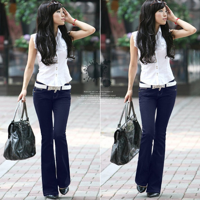

Row 16: category=Dresses, color=None, material=Knit


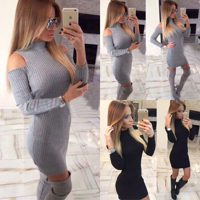

Row 17: category=Athletic Sets, color=None, material=None


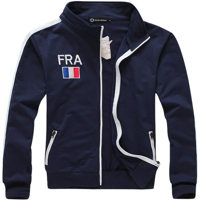

Row 18: category=Blouses, color=Black White, material=None


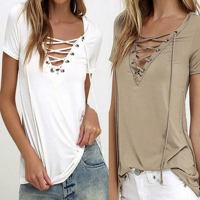

Row 19: category=None, color=Blue White, material=Polyester


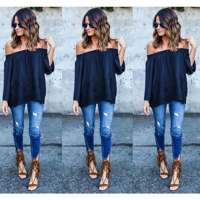

In [23]:
from datasets import load_dataset

ds = load_dataset("Marqo/iMaterialist", split="data", streaming=True)
for i, row in enumerate(ds):
    if i >= 20:
        
        break
    print(f"Row {i}: category={row.get('category')}, color={row.get('color')}, material={row.get('material')}")
    if row.get("image"):
        display(row["image"].resize((200, 200)))

## 3 · Load Florence-2 + LoRA

In [ ]:
from transformers import AutoModelForCausalLM, AutoProcessor
from peft import LoraConfig, get_peft_model

MODEL_ID = "microsoft/Florence-2-base"

processor = AutoProcessor.from_pretrained(MODEL_ID, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(MODEL_ID, trust_remote_code=True)

tok = processor.tokenizer
if not hasattr(tok, "image_token"):
    if "<image>" not in tok.get_vocab():
        tok.add_special_tokens({"additional_special_tokens": ["<image>"]})
    tok.image_token = "<image>"
    tok.image_token_id = tok.convert_tokens_to_ids("<image>")
    model.resize_token_embeddings(len(tok))

print(f"Base model loaded: {MODEL_ID}")

In [ ]:
LORA_R = 16
LORA_ALPHA = 32
LORA_DROPOUT = 0.05

lora_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules="all-linear",
)
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()
model.to(device);

## 4 · Build Datasets & Data Collator

In [ ]:
from dataclasses import dataclass
from typing import Dict, List
from torch.utils.data import Dataset

MAX_INPUT_LENGTH = 128
MAX_TARGET_LENGTH = 256


def read_jsonl(path: str) -> List[Dict]:
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            rows.append(json.loads(line))
    return rows


class FlorenceJsonlDataset(Dataset):
    def __init__(self, rows, processor, max_input_length, max_target_length, repo_root):
        self.rows = rows
        self.processor = processor
        self.max_input_length = max_input_length
        self.max_target_length = max_target_length
        self.repo_root = Path(repo_root)

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, idx):
        row = self.rows[idx]
        image_path = Path(row["image_path"])
        if not image_path.is_absolute():
            image_path = self.repo_root / image_path

        image = Image.open(image_path).convert("RGB")
        prompt = row["prompt"]
        target = row["target"]

        model_inputs = self.processor(
            text=prompt,
            images=image,
            return_tensors="pt",
            padding="max_length",
            truncation=True,
            max_length=self.max_input_length,
        )

        target_ids = self.processor.tokenizer(
            target,
            return_tensors="pt",
            padding="max_length",
            truncation=True,
            max_length=self.max_target_length,
        )["input_ids"].squeeze(0)

        target_ids[target_ids == self.processor.tokenizer.pad_token_id] = -100

        return {
            "input_ids": model_inputs["input_ids"].squeeze(0),
            "attention_mask": model_inputs["attention_mask"].squeeze(0),
            "pixel_values": model_inputs["pixel_values"].squeeze(0),
            "labels": target_ids,
        }


@dataclass
class DataCollator:
    def __call__(self, features):
        return {k: torch.stack([f[k] for f in features]) for k in features[0]}

In [ ]:
TRAIN_FILE = f"{PROCESSED_DIR}/train.jsonl"
VAL_FILE = f"{PROCESSED_DIR}/val.jsonl"

train_rows = read_jsonl(TRAIN_FILE)
val_rows = read_jsonl(VAL_FILE)

repo_root = Path.cwd()

train_dataset = FlorenceJsonlDataset(train_rows, processor, MAX_INPUT_LENGTH, MAX_TARGET_LENGTH, repo_root)
val_dataset = FlorenceJsonlDataset(val_rows, processor, MAX_INPUT_LENGTH, MAX_TARGET_LENGTH, repo_root)

print(f"Train: {len(train_dataset)} examples")
print(f"Val:   {len(val_dataset)} examples")

sample = train_dataset[0]
print(f"\nSample shapes:")
for k, v in sample.items():
    print(f"  {k}: {v.shape}")

## 5 · Train

In [ ]:
from transformers import TrainingArguments, Trainer

OUTPUT_DIR = "output/fashion-florence-lora"

EPOCHS = 3
LR = 2e-4
BATCH_SIZE = 2
GRAD_ACCUM = 8  # effective batch = BATCH_SIZE * GRAD_ACCUM = 16

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=EPOCHS,
    learning_rate=LR,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM,
    eval_strategy="steps",
    save_strategy="steps",
    eval_steps=200,
    save_steps=200,
    logging_steps=50,
    fp16=(device == "cuda"),
    bf16=False,
    weight_decay=0.01,
    warmup_ratio=0.05,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    report_to="none",
    dataloader_num_workers=2,
    remove_unused_columns=False,
    seed=42,
)

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=DataCollator(),
)

trainer.train()

In [ ]:
trainer.save_model(OUTPUT_DIR)
processor.save_pretrained(OUTPUT_DIR)
print(f"Model + processor saved to: {OUTPUT_DIR}")

### Training loss curve

In [ ]:
log_history = trainer.state.log_history
train_steps = [e["step"] for e in log_history if "loss" in e]
train_loss = [e["loss"] for e in log_history if "loss" in e]
eval_steps = [e["step"] for e in log_history if "eval_loss" in e]
eval_loss = [e["eval_loss"] for e in log_history if "eval_loss" in e]

plt.figure(figsize=(10, 4))
plt.plot(train_steps, train_loss, label="Train loss", alpha=0.7)
if eval_loss:
    plt.plot(eval_steps, eval_loss, label="Eval loss", marker="o", markersize=4)
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training Progress")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6 · Test Inference

Load the fine-tuned LoRA model and run it on a few test images.

In [ ]:
from peft import PeftModel

base_model = AutoModelForCausalLM.from_pretrained(MODEL_ID, trust_remote_code=True)
finetuned_model = PeftModel.from_pretrained(base_model, OUTPUT_DIR)
finetuned_model.to(device)
finetuned_model.eval()

finetuned_processor = AutoProcessor.from_pretrained(OUTPUT_DIR, trust_remote_code=True)
print("Fine-tuned model loaded.")

In [ ]:
PROMPT = "Analyze this clothing item image and return structured fashion tags as JSON."

test_path = Path(PROCESSED_DIR) / "test.jsonl"
test_rows = [json.loads(line) for line in test_path.read_text().strip().splitlines()[:6]]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for ax, row in zip(axes.flat, test_rows):
    img = Image.open(row["image_path"]).convert("RGB")
    inputs = finetuned_processor(text=PROMPT, images=img, return_tensors="pt").to(device)

    with torch.no_grad():
        generated_ids = finetuned_model.generate(
            **inputs,
            max_new_tokens=256,
            num_beams=3,
            early_stopping=True,
        )

    decoded = finetuned_processor.tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]

    expected = json.loads(row["target"])
    title = f"Pred: {decoded[:80]}...\n\nGT: {expected['category']} · {expected['primary_color']}"
    ax.imshow(img)
    ax.set_title(title, fontsize=7, ha="left", x=0)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 7 · Save to Google Drive (optional)

Persist the trained LoRA adapters so they survive Colab runtime resets.

In [ ]:
SAVE_TO_DRIVE = False  # flip to True to save

if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")

    DRIVE_OUTPUT = "/content/drive/MyDrive/fashion-florence-lora"
    !mkdir -p {DRIVE_OUTPUT}
    !cp -r {OUTPUT_DIR}/* {DRIVE_OUTPUT}/
    print(f"Saved to Google Drive: {DRIVE_OUTPUT}")
else:
    print("Skipping Drive save. Set SAVE_TO_DRIVE = True to persist.")